# Bootcamp Final Quiz

**Time Limit:** 60 minutes  
**Total Points:** 100  
**Format:** Open Internet — you may use Google, Stack Overflow, documentation, etc.  

---

### Rules
1. All code cells **must run without errors** when submitted
2. Write your markdown/text answers in the designated cells
3. Do **not** modify the Setup cell below
4. Questions build on each other — complete them in order
5. Read each question carefully before answering

### Grading Breakdown
| Section | Topic | Points |
|---------|-------|--------|
| 1 | Concepts & Warm-Up | 15 |
| 2 | Linear Regression & Metrics | 15 |
| 3 | Logistic Regression & Classification | 25 |
| 4 | Tree-Based Models | 25 |
| 5 | Model Pipeline & Deployment | 10 |
| 6 | Boss Level — End-to-End Challenge | 10 |
| **Total** | | **100** |

**Good luck!**

In [2]:
# ============================================================
# SETUP CELL — DO NOT MODIFY
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    GradientBoostingClassifier,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    mean_squared_error,
    r2_score,
    precision_recall_curve,
    auc,
)
from sklearn.datasets import make_classification
import joblib

# Load datasets
heart_df = pd.read_csv("heart.csv")
social_df = pd.read_csv("Social_Network_Ads.csv")

print(f"heart_df: {heart_df.shape[0]} rows, {heart_df.shape[1]} columns")
print(f"social_df: {social_df.shape[0]} rows, {social_df.shape[1]} columns")
print("\n✅ Setup complete — you're ready to go!")

heart_df: 289 rows, 14 columns
social_df: 400 rows, 5 columns

✅ Setup complete — you're ready to go!


---
## Section 1: Concepts & Warm-Up (15 pts)
*Estimated time: ~10 minutes*

---

### Q1 — Multi-Class vs Multi-Label (3 pts)

Consider these two scenarios:

- **Scenario A:** A model that classifies an email into **exactly one** category: Primary, Social, or Promotions.
- **Scenario B:** A model that tags a news article with **one or more** topics: Politics, Sports, Technology, Entertainment.

**Tasks:**
1. Which scenario is multi-class? Which is multi-label? (1 pt)
2. Give **one real-world example** of each that is NOT listed above. (2 pts)

1. Scenario A is multi-class and Scenario B is multi-label. This is the case because for the multi-class designation, mutual exclusivity between the categories
is required, while in the case of multi-label, an entity may have more than one label.*✏️ Your answer here:*

2. A real-world example can be seen in the field of medicine. A diagnostic for a specific disease, let's say lung cancer, is a different diagnosis from let's say colon cancer.
Both of these are considered separate diognoses but they may have in common certain health markers such as high levels of certain inflammatory factors, and others.
Categories: Lung Cancer, Testicular Canger, Colon Cancer
Labels: High Inflammatory I, High Inflammatory Parameter II, High Inflammatory Parameter II, Frequent Diseaness, High Blood Sugar


### Q2 — Bias-Variance Tradeoff (4 pts)

Two students trained a `RandomForestRegressor` on the same dataset with different `max_depth` settings. Here are their results:

| Model | max_depth | Train MSE (normalized) | Test MSE (normalized) |
|-------|-----------|----------------------|---------------------|
| Model A | 3 | 0.52 | 0.82 |
| Model B | 20 | 0.02 | 0.95 |

**Tasks:**
1. Which model is **underfitting**? Which is **overfitting**? Explain how you can tell from the numbers. (2 pts)
2. What is **bias** and what is **variance** in the context of these models? (1 pt)
3. What `max_depth` range would you experiment with next, and why? (1 pt)

1. Model A is underfitting and Model B is overfitting. One can tell this is the case because in the case of Model A, the train and test MSE's are both rather high and within
the same ball park. In the case of Model B, the train MSE is near zero, while the test mse is near 1, meaning that this model does great with the training data
but terribly with new data.

2. Bias and Variance in the context of these models are determined by their respective max_depth setting. The high bias Model A has a max_depth of 3, meaning that there are not
many branches in the decision trees involved and thus not much generalizability. At a max_depth of 3, Model A is not complex enough to account for the unknown. Model B on the other hand has too much complexity due to the max_depth of 20 of its many trees. This amount of tree branches tailors our model to the particuliarities of the training data set too well, making it unable to generalize to new data.

3. I would start by a max_depth in between the ones used above, say 7 or 8. The reasoning here being that we want to increase Model A's complexity without overfitting in the way that Model B did.


### Q3 — Encoding Categorical Variables (4 pts)

The `social_df` has a `Gender` column with values `Male` and `Female`.

**Tasks:**
1. In a markdown cell below, explain the difference between **Label Encoding** and **One-Hot Encoding**. When would you prefer one over the other? (2 pts)
2. Write code to create a one-hot encoded version of `Gender` and add it to the DataFrame. Print the first 5 rows showing the new columns. (2 pts)

1. Label Encoding encodes each unique label in a feature to an integer. One-Hot Encoding creates a matrix relationship of one's and zero's for each unique label in
a feature. Let's say that a feature has the unique label's ['Red', 'Green', 'Blue']. Label Encoding would replace these values as such: [0, 1, 2]. Whereas One-Hot Encoding
would do [[1, 0, 0], [0, 1, 0], [0, 0, 1]], where the unique labels are now the name of a column, and who's presence in a row is encoded row-wise by giving it a value of 1 while the other label's are zero.


In [29]:
# Q3 — Your code here
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()
gen_col = social_df[['Gender']]
encoded_gender = ohe.fit_transform(gen_col).toarray()
gen_df = pd.DataFrame(encoded_gender, columns=[f"{cat}_encoded" for cat in ohe.categories_[0]])
gen_df

social_df = pd.concat([social_df, gen_df], axis=1).drop('Gender',axis=1)

### Q4 — Train-Test Split (4 pts)

Prepare the `heart_df` dataset for modeling.

**Tasks:**
1. Separate features (`X`) and target (`y`) — the target column is `"target"` (2 pts)
2. Perform an **80/20** train-test split with `random_state=42` (1 pt)
3. Print the shape of `X_train`, `X_test`, `y_train`, `y_test` (1 pt)

**⚠️ Store the results as `X_train, X_test, y_train, y_test` — you will reuse these in later sections!**

In [4]:
X = heart_df.drop('output',axis=1)
y = heart_df['output']
X
y

,output
0,1
1,1
2,1
3,1
4,1
...,...
284,0
285,0
286,0
287,0


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_test, y_train, y_test

X

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall
0,60,1,3,145,233,1,0,150,0,2.3,0,0,1
1,35,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,55,1,1,120,236,0,1,178,0,0.8,2,0,2
4,56,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
284,60,1,0,140,207,0,0,138,1,1.9,2,1,3
285,46,1,0,140,311,0,1,120,1,1.8,1,2,3
286,59,1,3,134,204,0,1,162,0,0.8,2,2,2
287,54,1,1,154,232,0,0,164,0,0.0,2,1,2


---
## Section 2: Linear Regression & Metrics (15 pts)
*Estimated time: ~10 minutes*

---

### Q5 — Bug Hunt: Gradient Descent (5 pts)

The code below implements gradient descent to fit a line predicting `thalach` (max heart rate) from `age` using the heart dataset. **But it has 3 bugs!**

**Tasks:**
1. Find and fix all **3 bugs** (3 pts)
2. Add a comment next to each fix explaining what was wrong (1 pt)
3. After fixing, the MSE should decrease over iterations. Print the final MSE. (1 pt)

[np.float64(0.9999999999999996), np.float64(0.9700368326932357), np.float64(0.945766667174757), np.float64(0.9261078331047891), np.float64(0.9101841775081152), np.float64(0.8972860164748093), np.float64(0.8868385060378313), np.float64(0.8783760225838794), np.float64(0.8715214109861783), np.float64(0.8659691755920402), np.float64(0.8614718649227886), np.float64(0.8578290432806949), np.float64(0.8548783577505987), np.float64(0.8524883024712209), np.float64(0.8505523576949249), np.float64(0.8489842424261251), np.float64(0.8477140690583972), np.float64(0.8466852286305377), np.float64(0.8458518678839717), np.float64(0.8451768456792529), np.float64(0.8446300776934307), np.float64(0.844187195624915), np.float64(0.843828461149417), np.float64(0.8435378862242637), np.float64(0.8433025205348896), np.float64(0.8431118743264965), np.float64(0.8429574508976982), np.float64(0.8428323679203714), np.float64(0.8427310507087368), np.float64(0.8426489837673128), np.float64(0.8425825095447593), np.float64

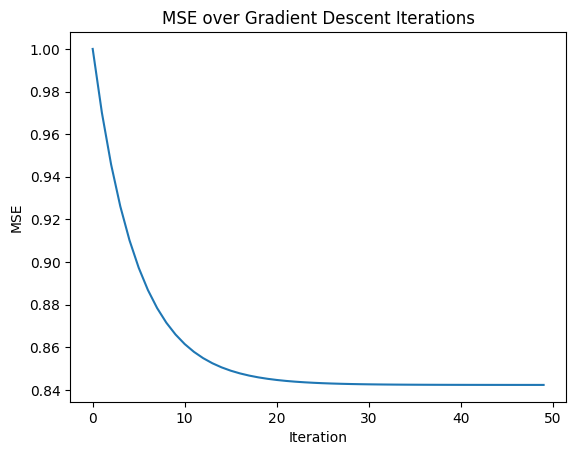

In [6]:
# Q5 — Find and fix the 3 bugs in this gradient descent implementation

# Data preparation
gd_X = heart_df["age"].values.astype(float)
gd_y = heart_df["thalachh"].values.astype(float)

# Normalize
gd_X = (gd_X - gd_X.mean()) / gd_X.std()
gd_y = (gd_y - gd_y.mean()) / gd_y.std()

# Initialize parameters
theta_0, theta_1 = 0.0, 0.0
learning_rate = 0.1
num_iterations = 50

mse_history = []

for iteration in range(num_iterations):
    # Predict
    y_pred = theta_0 + theta_1 * gd_X

    # Compute errors
    errors = gd_y - y_pred

    # BUG 1 is somewhere in the MSE calculation
    mse = np.mean(errors**2) # the error needed to be squared
    mse_history.append(mse)

    # BUG 2 is somewhere in the theta_0 update
    theta_0 = theta_0 + learning_rate * np.mean(errors) # the step size must be added to theta_0

    # BUG 3 is somewhere in the theta_1 update
    theta_1 = theta_1 + learning_rate * np.mean(errors * gd_X) # errors must be multiplied by the data gd_X
print(mse_history)
print(f"Final MSE: {mse_history[-1]:.4f}")
plt.plot(mse_history)
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("MSE over Gradient Descent Iterations")
plt.show()

### Q6 — MAE vs MSE: Manual Computation (5 pts)

Using the `heart_df`, fit a `LinearRegression` to predict `thalach` (max heart rate) from `age`.

**Tasks:**
1. Fit the model on the full `heart_df` (1 pt)
2. Compute **MAE** manually (without sklearn): `np.mean(np.abs(y - y_pred))` (1 pt)
3. Compute **MSE** manually (without sklearn): `np.mean((y - y_pred) ** 2)` (1 pt)
4. Print both values (1 pt)
5. Answer in markdown: *"If one patient had an actual max heart rate of 200 but the model predicted 100, which metric (MAE or MSE) would be more affected by this single outlier, and why?"* (1 pt)

In [9]:
# Q6 — Your code here
from sklearn.linear_model import LinearRegression
X2 = heart_df.copy()
y2 = X2['thalachh']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2[['age']], y2, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X2_train, y2_train)

y2_pred = lr.predict(X2_test)

error = y2_test - y2_pred

absolute_error = np.abs(error)
MAE = np.mean(absolute_error)

squared_error = error**2
MSE = np.mean(squared_error)

print(f"MAE: {MAE} ------- MSE: {MSE}")

lr.intercept_
y2.describe()

MAE: 15.941695060314755 ------- MSE: 391.46425229805794


,thalachh
count,289.000000
mean,150.231834
std,22.899650
min,71.000000
25%,136.000000
50%,154.000000
75%,168.000000
max,202.000000


The mean squared error would be most affected by this outlier. This is so because MSE squares the errors, making the difference 200 - 100 = 100 equal to an error for that prediction 10,000. MSE is more sensitive to outliers for this reason.



### Q7 — Z-Score Normalization (5 pts)

**Tasks:**
1. Apply z-score normalization to `thalach`: `(thalach - mean) / std` (2 pts)
2. Fit a `LinearRegression` on `age` (raw, not normalized) vs `thalach` (normalized) (1 pt)
3. Print the model's `coef_` and `intercept_` (1 pt)
4. In markdown: what does the `intercept_` represent when the target is normalized? (1 pt)

In [16]:
y2_norm = y2 - np.mean(y2)/ np.std(y2)
age = X[['age']]

age_train, age_test, y2_norm_train, y2_norm_test = train_test_split(age, y2_norm, test_size=0.2, random_state=42)

lr2 = LinearRegression()
lr2.fit(age_train, y2_norm_train)

print(f"intercept: {lr2.intercept_} -----------------coefficient: {lr2.coef_}")
y2_norm.describe()
X[X['age'] == 34]

intercept: 199.08134040994133 -----------------coefficient: [-1.02385541]


,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall
58,34,1,3,118,182,0,0,174,0,0.0,2,0,2
125,34,0,1,118,210,0,1,192,0,0.7,2,0,2


*✏️ Your intercept answer here:*


---
## Section 3: Logistic Regression & Classification Metrics (25 pts)
*Estimated time: ~12 minutes*

---

### Q8 — Logistic Regression with Two Features (4 pts)

In class, we trained a `LogisticRegression` on `social_df` using **only Age**. Now let's try both features.

**Tasks:**
1. Use **both** `Age` AND `EstimatedSalary` as features, `Purchased` as target (1 pt)
2. Train-test split: 80/20, `random_state=42` (1 pt)
3. Train a `LogisticRegression` and print the `classification_report` on the **test** set (1 pt)
4. In markdown: does adding `EstimatedSalary` improve results compared to using only `Age`? Why might that be? (1 pt)

**⚠️ Store your social network variables as `social_X_train, social_X_test, social_y_train, social_y_test` and the model as `social_model` — used in Q9-Q11.**

In [42]:
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression

X = social_df[["Age", "EstimatedSalary"]]
y = social_df['Purchased']

social_X_train, social_X_test, social_y_train, social_y_test = train_test_split(X, y, test_size=0.2, random_state=42)

social_model = LogisticRegression()
social_model.fit(social_X_train, social_y_train)

y_test_pred = social_model.predict(social_X_test)

print(classification_report(social_y_test, y_test_pred))





              precision    recall  f1-score   support

           0       0.88      0.96      0.92        52
           1       0.91      0.75      0.82        28

    accuracy                           0.89        80
   macro avg       0.90      0.86      0.87        80
weighted avg       0.89      0.89      0.88        80



In [22]:
# from sklearn.metrics import classification_report
# from sklearn.linear_model import LogisticRegression

# X = social_df[["Age"]]
# y = social_df['Purchased']

# social_X_train, social_X_test, social_y_train, social_y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# social_model = LogisticRegression()
# social_model.fit(social_X_train, social_y_train)

# y_pred_test = social_model.predict(social_X_test)

# print(classification_report(social_y_test, y_pred_test))

# social_df

              precision    recall  f1-score   support

           0       0.91      0.96      0.93        52
           1       0.92      0.82      0.87        28

    accuracy                           0.91        80
   macro avg       0.91      0.89      0.90        80
weighted avg       0.91      0.91      0.91        80



,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


Adding 'EstimatedSalary' makes the results worse. It may be that this feature is simpy noise, i.e., not relevant to the output of making a purchase. It would appear that age is the most important feature to make accurate predictions of user purchase.




### Q9 — Manual Confusion Matrix (5 pts)

Using `social_model` from Q8:

**Tasks:**
1. Get predictions on the test set (1 pt)
2. Manually compute **TP, TN, FP, FN** using the boolean indexing pattern from class (2 pts):  
   `tp = y_test[(y_test == 1) & (y_pred == 1)].sum()`
3. Manually compute **precision** and **recall** from your TP/TN/FP/FN values (1 pt)
4. Verify your manual values match `precision_score()` and `recall_score()` from sklearn — print both to confirm (1 pt)

In [71]:
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import precision_recall_curve

y_test_pred = social_model.predict(social_X_test)

tp = social_y_test[(social_y_test == 1) & (y_test_pred == 1)].count()
tn = social_y_test[(social_y_test == 0) & (y_test_pred == 0)].count()
fp = social_y_test[(social_y_test == 0) & (y_test_pred == 1)].count()
fn = social_y_test[(social_y_test == 1) & (y_test_pred == 0)].count()

precision = tp / (tp + fp)
recall = tp / (tp + fn)

print(f"Precision: {precision}\nRecall: {recall}")

print(f"precision_score: {precision_score(social_y_test, y_test_pred)}\nrecall_score:{recall_score(social_y_test, y_test_pred)}")






Precision: 0.9130434782608695
Recall: 0.75
precision_score: 0.9130434782608695
recall_score:0.75


### Q10 — Threshold Tuning (6 pts)

Using `social_model` from Q8:

**Tasks:**
1. Get predicted probabilities using `predict_proba()` — use the **positive class** column (1 pt)
2. Sweep thresholds from **0.0 to 1.0** in steps of **0.05** (1 pt)
3. For each threshold, convert probabilities to predictions using: `[1 if p >= threshold else 0 for p in probs]` (1 pt)
4. Compute precision and recall at each threshold (1 pt)
5. Plot **precision** and **recall** as two lines against threshold (1 pt)
6. In markdown: At approximately what threshold do precision and recall cross? What does this crossing point mean for the Social Network Ads business case? (1 pt)

In [74]:
preds = social_model.predict_proba(social_X_test)[:,1]
preds

thresholds = np.arange(0,1,0.05)

predictions = [1 if p >= thr else 0 for p in preds for thr in thresholds]

for thr in thresholds:
  predictions = [1 if p >=thr else 0 for p in preds]
  print(f"For threshold {thr}===> ")
  print(f"Precision: {precision_score(social_y_test, predictions)}")
  print(f"Recall: {recall_score(social_y_test, predictions)}\n\n")





For threshold 0.0===> 
Precision: 0.35
Recall: 1.0


For threshold 0.05===> 
Precision: 0.4827586206896552
Recall: 1.0


For threshold 0.1===> 
Precision: 0.5833333333333334
Recall: 1.0


For threshold 0.15000000000000002===> 
Precision: 0.6829268292682927
Recall: 1.0


For threshold 0.2===> 
Precision: 0.717948717948718
Recall: 1.0


For threshold 0.25===> 
Precision: 0.7567567567567568
Recall: 1.0


For threshold 0.30000000000000004===> 
Precision: 0.8064516129032258
Recall: 0.8928571428571429


For threshold 0.35000000000000003===> 
Precision: 0.8
Recall: 0.8571428571428571


For threshold 0.4===> 
Precision: 0.8518518518518519
Recall: 0.8214285714285714


For threshold 0.45===> 
Precision: 0.9130434782608695
Recall: 0.75


For threshold 0.5===> 
Precision: 0.9130434782608695
Recall: 0.75


For threshold 0.55===> 
Precision: 0.95
Recall: 0.6785714285714286


For threshold 0.6000000000000001===> 
Precision: 0.95
Recall: 0.6785714285714286


For threshold 0.65===> 
Precision: 0.947368

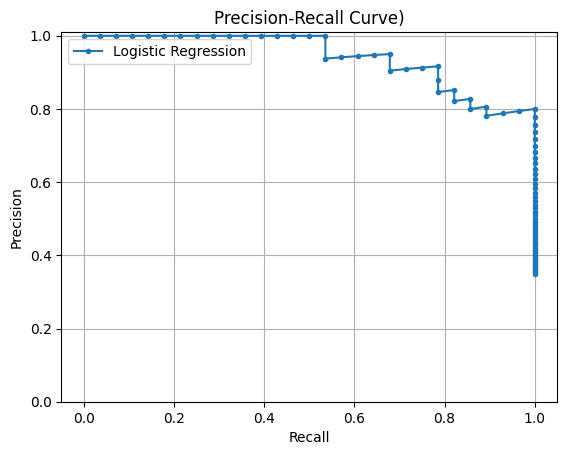

In [73]:
precision, recall, _ = precision_recall_curve(social_y_test, preds)

plt.plot(recall, precision,marker=".",label="Logistic Regression")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.ylim([0.0, 1.01])

plt.show()

At threshold .30 we see that precision breaches 80% and threshold begins its descent from a perfect 100% to an 89%. It's at this point where the situation will dictate the appropriateness of decreasing the threshold a bit even though precision will decrease, or to increase the threshold for the sake of high precision while false negatives.


### Q11 — Precision-Recall Curve & AUC (5 pts)

Using `social_model` from Q8:

**Tasks:**
1. Compute the precision-recall curve using `precision_recall_curve()` from sklearn (1 pt)
2. Compute the **AUC** (Area Under Curve) using `auc(recall, precision)` (1 pt)
3. Compute the **no-skill baseline**: `len(y_test[y_test == 1]) / len(y_test)` (1 pt)
4. Plot the PR curve with the no-skill baseline as a horizontal dashed line. Include labels and a legend. (1 pt)
5. In markdown: what does a higher AUC value tell you about your model? What would an AUC of 0.5 mean? (1 pt)

In [ ]:
# Q11 — Your code here

*✏️ Your AUC analysis here:*


### Q12 — The Hospital Dilemma (5 pts)

A hospital builds a model to predict **heart disease** using the `heart_df` dataset. The model achieves:
- **Precision: 95%**
- **Recall: 60%**

The hospital administrator says:  
> *"This is great! When we say someone has heart disease, we're right 95% of the time."*

A doctor disagrees and says the model is **dangerous**.

**Tasks:**
1. Who is correct — the administrator or the doctor? Explain your reasoning. (2 pts)
2. What does 60% recall **actually mean** in terms of real patients? How many sick patients are being missed? (1 pt)
3. Which metric matters more for this use case — precision or recall? Why? (1 pt)
4. Name **one concrete action** you would take to improve recall (e.g., threshold adjustment, more data, different model). (1 pt)

1. If standard medical procedure dictates that getting a positive test result will lead to more clarifying testing, while negative results will result in a patient being sent home, then the doctor is correct and having a recall of 60% is dangerous. If the paramount priority is a patient's health and wellbeing then to miss patient's illness must be taken as an unacceptable outcome.
2. A recall of 60% percent means that out of 1000 patients, 400 will go home believing that they do not have heart disease and will therefore not intervene at all in preventing an early death.
3. Recall matters more in this case. By far.
4. One can simpy adjust the threshold in this case and send pateient's flagged as positive for secondary testing.


---
## Section 4: Tree-Based Models (25 pts)
*Estimated time: ~12 minutes*

---

### Q13 — Decision Tree Visualization & Feature Importance (6 pts)

Using the `X_train, X_test, y_train, y_test` from **Q4** (heart dataset):

**Tasks:**
1. Train a `DecisionTreeClassifier` with `max_depth=3` and `random_state=42` (1 pt)
2. Visualize the tree using `plot_tree()` with `filled=True`, `feature_names`, and `class_names=["No Disease", "Disease"]` (2 pts)
3. Print `feature_importances_` as a pandas Series, sorted from highest to lowest (2 pts)
4. In markdown: which feature is the most important? Does this make intuitive medical sense? (1 pt)

,0
thall,0.527689
thalachh,0.190410
cp,0.131487
sex,0.064456
age,0.044303
oldpeak,0.041654
trtbps,0.000000
chol,0.000000
fbs,0.000000
exng,0.000000


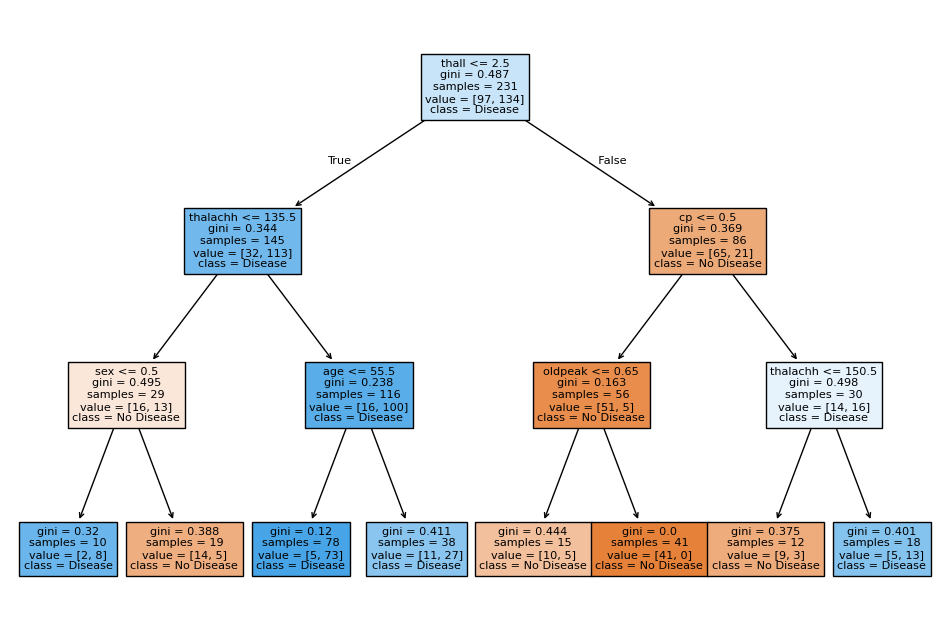

In [90]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
Xh = heart_df.copy().drop('output', axis=1)
yh = heart_df['output']

Xh_train, Xh_test, yh_train, yh_test = train_test_split(Xh, yh, test_size=0.2, random_state=42)

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(Xh_train, yh_train)

yh_test_pred = dt.predict(Xh_test)

plt.figure(figsize=(12,8))
plot_tree(dt, filled=True, feature_names=Xh.columns, class_names=["No Disease", "Disease"])
#plt.show()

most_important_features = pd.Series(dt.feature_importances_, index=Xh.columns).sort_values(ascending=False)
most_important_features

### Q14 — predict vs predict_proba (6 pts)

Using the decision tree from Q13:

**Tasks:**
1. Create a DataFrame with the following columns for the **first 10 test samples** (3 pts):
   - `Actual` — true labels from `y_test`
   - `Predicted` — model predictions
   - `Prob_No_Disease` — probability of class 0
   - `Prob_Disease` — probability of class 1
2. Display the DataFrame (1 pt)
3. Find the sample where the model is **least confident** (probability closest to 0.5). Print its index and probabilities. (1 pt)
4. In markdown: what does it mean when `predict_proba` gives [0.5, 0.5]? How does the decision tree produce these probabilities? (1 pt)

In [112]:
ytp_s = pd.Series(yh_test_pred).head(10)
yt_s = pd.Series(np.array(yh_test))
pp_no = pd.Series(dt.predict_proba(Xh_test)[:, 0])
pp_yes = pd.Series(dt.predict_proba(Xh_test)[:, 1])

df = pd.DataFrame([yt_s, ytp_s, pp_no, pp_yes], index=["Actual","Predicted","Prob_No_Disease","Prob_Disease" ]).T.head(10)

print(df[df['Prob_Disease'] < .8])
# Model's probability closest to and above 0.5 for 'Prob_Disease' is 0.710526

print(df[df['Prob_No_Disease'] < .8])
# Model's probability closest to and above 0.5 for 'Prob_No_Disease' is 0.736842



   Actual  Predicted  Prob_No_Disease  Prob_Disease
2     0.0        0.0         0.736842      0.263158
4     0.0        0.0         1.000000      0.000000
5     1.0        1.0         0.289474      0.710526
7     0.0        1.0         0.289474      0.710526
8     1.0        1.0         0.289474      0.710526
9     0.0        0.0         1.000000      0.000000
   Actual  Predicted  Prob_No_Disease  Prob_Disease
0     1.0        1.0         0.064103      0.935897
1     1.0        1.0         0.064103      0.935897
2     0.0        0.0         0.736842      0.263158
3     1.0        1.0         0.064103      0.935897
5     1.0        1.0         0.289474      0.710526
6     1.0        1.0         0.064103      0.935897
7     0.0        1.0         0.289474      0.710526
8     1.0        1.0         0.289474      0.710526


### Q15 — Ensemble Showdown: DT vs RF vs GB (7 pts)

Using the `X_train, X_test, y_train, y_test` from **Q4** (heart dataset):

**Tasks:**
1. Train all three models (3 pts):
   - `DecisionTreeClassifier(random_state=42)`
   - `RandomForestClassifier(n_estimators=20, random_state=42)`
   - `GradientBoostingClassifier(n_estimators=20, random_state=42)`
2. Print the **test accuracy** for each model using `accuracy_score` (1 pt)
3. Create a **bar plot** comparing the three accuracies (1 pt)
4. In markdown, answer BOTH: (2 pts)
   - What is **bagging** and how does Random Forest use it?
   - What is the key difference between **bagging** (Random Forest) and **boosting** (Gradient Boosting)?

dtc_acc: 0.7413793103448276
rfc_acc: 0.8275862068965517
gbc_acc: 0.8275862068965517


<BarContainer object of 3 artists>

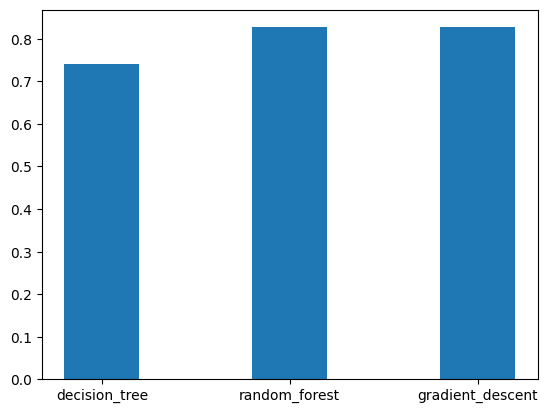

In [123]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score

dtc = DecisionTreeClassifier(random_state=42)
rfc = RandomForestClassifier(n_estimators=20, random_state=42)
gbc = GradientBoostingClassifier(n_estimators=20, random_state=42)

dtc.fit(X_train,y_train)
rfc.fit(X_train,y_train)
gbc.fit(X_train,y_train)

dtc_pred = dtc.predict(X_test)
rfc_pred = rfc.predict(X_test)
gbc_pred = gbc.predict(X_test)

dtc_acc = accuracy_score(y_test , dtc_pred)
rfc_acc = accuracy_score(y_test, rfc_pred)
gbc_acc = accuracy_score(y_test, gbc_pred)

print(f"dtc_acc: {dtc_acc}\nrfc_acc: {rfc_acc}\ngbc_acc: {gbc_acc}")

plt.bar(['decision_tree','random_forest','gradient_descent'],height=[dtc_acc, rfc_acc, gbc_acc], width=[.4, .4, .4])



1. Bagging is short for Bootstrap+Aggregation and it works by taking the training data, selecting a random sample from it with replacement, and training a decision tree from this sample. This is the bootstrapping part. The ensemble method, say RandomForestClassifier, then aggregates the results of all of its decision tree.

2. Boosting on the other hand takes the training data set, takes the result from the trained individual tree, and reuses the initial dataset but with weights associated to the sample that was not correctly predicted. The weights in the case of GradientBoostedClassifier are based on Gradient Descent.


### Q16 — Overfitting Experiment (6 pts)

Using the `X_train, X_test, y_train, y_test` from **Q4** (heart dataset):

**Tasks:**
1. Train a `RandomForestClassifier(n_estimators=20, random_state=42)` with each `max_depth` in: `[2, 3, 5, 10, None]` (2 pts)
2. For each, record the **train accuracy** and **test accuracy** (1 pt)
3. Plot both curves on the same graph (x-axis = max_depth, y-axis = accuracy). Use labels and a legend. Replace `None` with a label like `"None"` on the x-axis. (2 pts)
4. In markdown: at which `max_depth` does overfitting start? How can you tell? (1 pt)

In [125]:
for i in [2, 3, 5, 10, None]:
  rfc2 = RandomForestClassifier(max_depth = i, n_estimators=20, random_state=42)
  rfc2.fit(X_train, y_train)

  train_pred = rfc2.predict(X_train)
  test_pred = rfc2.predict(X_test)
  print(f"For Max Depth of {i}:")
  print(f"Train Accuracy: {accuracy_score(y_train, train_pred)} , Test Accuracy: {accuracy_score(y_test, test_pred)}")
  print("======================")

For Max Depth of 2:
Train Accuracy: 0.8441558441558441 , Test Accuracy: 0.7931034482758621
For Max Depth of 3:
Train Accuracy: 0.8701298701298701 , Test Accuracy: 0.8275862068965517
For Max Depth of 5:
Train Accuracy: 0.9393939393939394 , Test Accuracy: 0.7931034482758621
For Max Depth of 10:
Train Accuracy: 0.9956709956709957 , Test Accuracy: 0.8103448275862069
For Max Depth of None:
Train Accuracy: 1.0 , Test Accuracy: 0.8275862068965517


The overfitting begins to take place at max_depth=5. It's here where the train accuracy leaps forward while the test accuracy decreases. In the subsequent max depth of 10, the train accuracy increases at an even higher rate while the test accuracy increases by barely a point.


---
## Section 5: Model Pipeline & Deployment (10 pts)
*Estimated time: ~8 minutes*

---

### Q17 — Model Serialization with joblib (3 pts)

**Tasks:**
1. Take the **best-performing model** from Q15 (whichever had the highest test accuracy) (1 pt)
2. Save it to `"data/quiz_best_model.pkl"` using `joblib.dump()` (1 pt)
3. Load it back with `joblib.load()`, run predictions on `X_test`, and verify they match the original predictions using `np.array_equal()`. Print the result. (1 pt)

In [126]:
import joblib

joblib.dump(rfc2, "quiz_best_model.pkl")


['quiz_best_model.pkl']

In [131]:
rfc_load = joblib.load('quiz_best_model.pkl')

load_pred = rfc_load.predict(X_test)

print(np.array_equal(rfc_pred, load_pred))

True


### Q18 — FastAPI Design (4 pts)

You want to deploy your heart disease model as a REST API using **FastAPI**.

**Tasks — answer in the markdown cell below (pseudocode/code is fine, it doesn't need to run):**

1. Write a **Pydantic `BaseModel`** class called `HeartFeatures` with all 13 feature fields from `heart.csv`, using appropriate types (`int` or `float`). (1 pt)
2. Write a `POST /predict` endpoint that: accepts `HeartFeatures`, converts it to a DataFrame, runs the model prediction, and returns `{"prediction": 0 or 1, "probability": float}`. (1 pt)
3. What **logging** would you add to this endpoint? List at least 3 log messages with their appropriate levels (DEBUG, INFO, WARNING, ERROR, CRITICAL). (1 pt)
4. What **error handling** would you add? Describe at least 2 scenarios that could go wrong and how you'd handle them. (1 pt)



```
# This is formatted as code
```

*✏️ Your FastAPI design here:*


In [134]:
from pydantic import BaseModel
from fastapi import FastAPI

app = FastAPI()

class HeartFeatures(BaseModel):
  age: int
  sex: int
  cp: int
  trtbps: int
  chol: int
  fbs: int
  restecg: int
  thalachh: int
  exng: int
  oldpeak: float
  slp: int
  caa: int
  thall: int

mod = joblib.load('quiz_best_model.pkl')
@app.post('url/predict')
def predict(features: HeartFeatures):
  X = pd.DataFrame([features.model_dump()])

  prediction = mod.predict(X)

  return {"Has Disease": prediction}




Index(['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'restecg', 'thalachh',
       'exng', 'oldpeak', 'slp', 'caa', 'thall', 'output'],
      dtype='object')

### Q19 — Load Testing Design (3 pts)

You've deployed your heart disease API and need to verify it can handle traffic.

**Tasks — answer in the markdown cell below:**

1. What Python library/class would you use to send **500 concurrent requests**? (1 pt)
2. Write a function signature `run_load_test(num_requests: int)` and describe in pseudocode what it does (generate random data, send requests, collect results). (1 pt)
3. What **3 metrics** would you collect and report at the end of the load test? (1 pt)

*✏️ Your load testing design here:*


---
## Section 6: Boss Level — End-to-End Challenge (10 pts)
*Estimated time: ~8 minutes*

---

### Q20 — Full ML Pipeline (10 pts)

Using `social_df`, build a **complete ML pipeline** from scratch:

1. **Feature Engineering (2 pts):** Create at least **one new feature** (e.g., `Age_Salary_Ratio = Age / EstimatedSalary`, or binning Age into groups, or any creative transformation). Use both `Age` and `EstimatedSalary` plus your new feature(s) as inputs.

2. **Model Training (2 pts):** Train a `GradientBoostingClassifier` on your features.

3. **Threshold Optimization (2 pts):** Using `predict_proba`, find the threshold that maximizes the **F1 score** (hint: F1 = 2 * precision * recall / (precision + recall)). Print the optimal threshold and the F1 at that threshold.

4. **Final Evaluation (2 pts):** Apply your optimal threshold to the test set predictions. Print the `classification_report` at your chosen threshold.

5. **Save & Report (2 pts):**
   - Save the model to `"data/quiz_boss_model.pkl"` using joblib
   - In a markdown cell below, write a **3-sentence model report** explaining: what features you used, what threshold you chose and why, and how the model performed.

In [163]:
social_df
social_df['Age_Salary_Ratio'] = social_df['Age']/social_df['EstimatedSalary']
Xz = pd.concat([social_df['Age_Salary_Ratio'],social_df],axis=1).drop('Purchased',axis=1)
yz = social_df['Purchased']

Xz_train, Xz_test, yz_train, yz_test = train_test_split(Xz, yz, test_size=0.2, random_state=42)

gbz = GradientBoostingClassifier()
gbz.fit(Xz_train, yz_train)

gbz_probas = gbz.predict_proba(Xz_test)[:, 1]
thresholdsz = np.arange(0, 1, 0.05)
f1_scores = []

for thr in thresholdsz:
    preds = [1 if p >= thr else 0 for p in gbz_probas]
    f1 = (2*precision_score(yz_test, preds)*accuracy_score(yz_test, preds))\
                      /(precision_score(yz_test, preds) + accuracy_score(yz_test, preds))
    f1_scores.append({'f1': [thr, f1]})

max_f1 = max(f1_scores, key=lambda x:x['f1'][1])['f1']
print(f"Max f1 of {max_f1[1]} at threshold {max_f1[0]}")

gbz_predictions = pd.Series(gbz.predict(Xz_test))

gbz_probas > max_f1[0]
gbz_predictions[gbz_probas >= max_f1[0]].count()




Max f1 of 0.8837340876944836 at threshold 0.75


np.int64(25)

*✏️ Your 3-sentence model report here:*


---

## You're Done!

**Before submitting:**
1. **Restart the kernel** and **Run All Cells** — make sure everything runs without errors
2. Check that all markdown answers are filled in (search for `✏️`)
3. Save the notebook

**Good work!** 🎉